In [83]:
import matplotlib.pyplot as plt
import pandas as pd

In [84]:
slopes_df = pd.read_csv("slopes_df_30menit.csv")

In [85]:
# ======================
# SETUP
# ======================
# contoh target_date (ubah sesuai kebutuhan)
target_date = pd.to_datetime("2025-04-21")


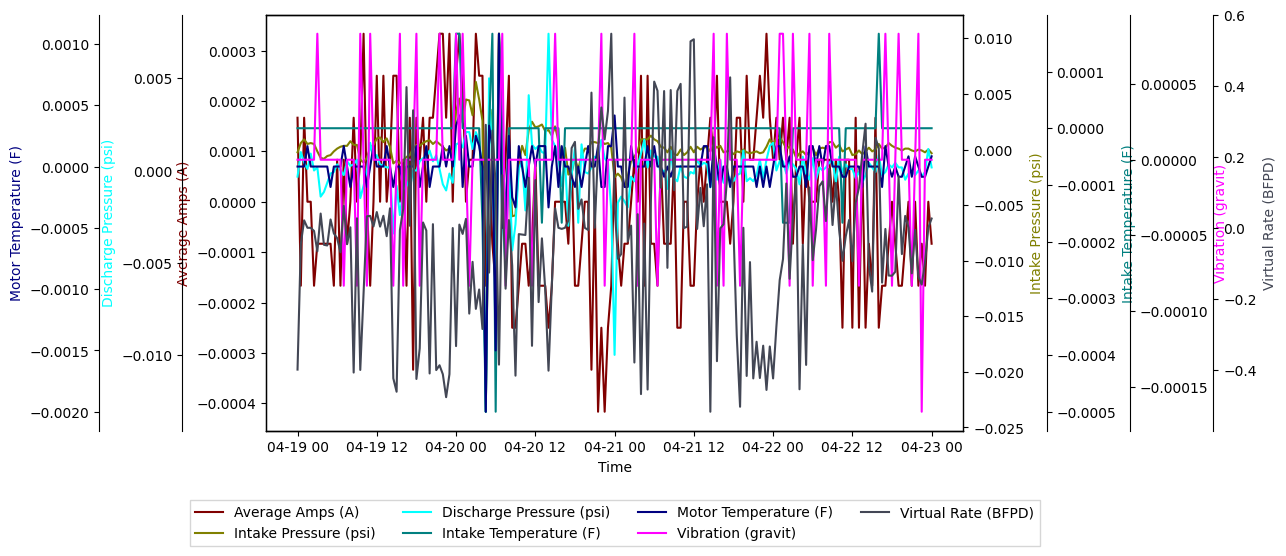

In [86]:

# Konversi kolom waktu
slopes_df["Window_Start_Time"] = pd.to_datetime(slopes_df["Window_Start_Time"])

# Buat rentang waktu ±2 hari
start_date = target_date - pd.Timedelta(days=2)
end_date = target_date + pd.Timedelta(days=2)

# Filter sesuai rentang
ready = slopes_df[(slopes_df["Window_Start_Time"] >= start_date) &
                  (slopes_df["Window_Start_Time"] <= end_date)]

# Cek apakah ada data
if ready.empty:
    print(f"Tidak ada data antara {start_date} dan {end_date}")
else:
    # pastikan jadi array 1D
    x = ready["Window_Start_Time"].to_numpy().ravel()

    # ======================
    # PLOTTING
    # ======================
    fig = plt.figure(figsize=(12, 6))
    host = fig.add_subplot(111)

    par1 = host.twinx()
    par2 = host.twinx()
    par3 = host.twinx()
    par4 = host.twinx()
    par5 = host.twinx()
    par6 = host.twinx()

    host.set_xlabel("Time")
    host.set_ylabel("Average Amps (A)")
    par1.set_ylabel("Intake Pressure (psi)")
    par2.set_ylabel("Discharge Pressure (psi)")
    par3.set_ylabel("Intake Temperature (F)")
    par4.set_ylabel("Motor Temperature (F)")
    par5.set_ylabel("Vibration (gravit)")
    par6.set_ylabel("Virtual Rate (BFPD)")

    p1, = host.plot(x, ready["A"].to_numpy().ravel(), color='#800000', label="Average Amps (A)")
    p2, = par1.plot(x, ready["IP"].to_numpy().ravel(), color='#808000', label="Intake Pressure (psi)")
    p3, = par2.plot(x, ready["DP"].to_numpy().ravel(), color='#00ffff', label="Discharge Pressure (psi)")
    p4, = par3.plot(x, ready["IT"].to_numpy().ravel(), color='#018080', label="Intake Temperature (F)")
    p5, = par4.plot(x, ready["MT"].to_numpy().ravel(), color='#000080', label="Motor Temperature (F)")
    p6, = par5.plot(x, ready["V"].to_numpy().ravel(), color='#ff00ff', label="Vibration (gravit)")
    p7, = par6.plot(x, ready["R"].to_numpy().ravel(), color='#434755', label="Virtual Rate (BFPD)")

    # Shrink axis supaya muat legend
    box = host.get_position()
    host.set_position([box.x0, box.y0, box.width * 0.75, box.height * 0.9])

    # Legend
    lns = [p1, p2, p3, p4, p5, p6, p7]
    host.legend(handles=lns, loc='upper center', bbox_to_anchor=(0.5, -0.15),
                fancybox=False, shadow=False, ncol=4)

    # Spines & ticks
    par2.spines['left'].set_position(('outward', 60))
    par3.spines['right'].set_position(('outward', 60))
    par4.spines['left'].set_position(('outward', 120))
    par5.spines['right'].set_position(('outward', 120))
    par6.spines['right'].set_position(('outward', 180))

    par2.yaxis.set_ticks_position('left')
    par3.yaxis.set_ticks_position('right')
    par4.yaxis.set_ticks_position('left')
    par5.yaxis.set_ticks_position('right')
    par6.yaxis.set_ticks_position('right')

    par2.yaxis.set_label_position('left')
    par3.yaxis.set_label_position('right')
    par4.yaxis.set_label_position('left')
    par5.yaxis.set_label_position('right')
    par6.yaxis.set_label_position('right')

    # Warna label sesuai plot
    host.yaxis.label.set_color(p1.get_color())
    par1.yaxis.label.set_color(p2.get_color())
    par2.yaxis.label.set_color(p3.get_color())
    par3.yaxis.label.set_color(p4.get_color())
    par4.yaxis.label.set_color(p5.get_color())
    par5.yaxis.label.set_color(p6.get_color())
    par6.yaxis.label.set_color(p7.get_color())

    plt.show()

# SIMPEL

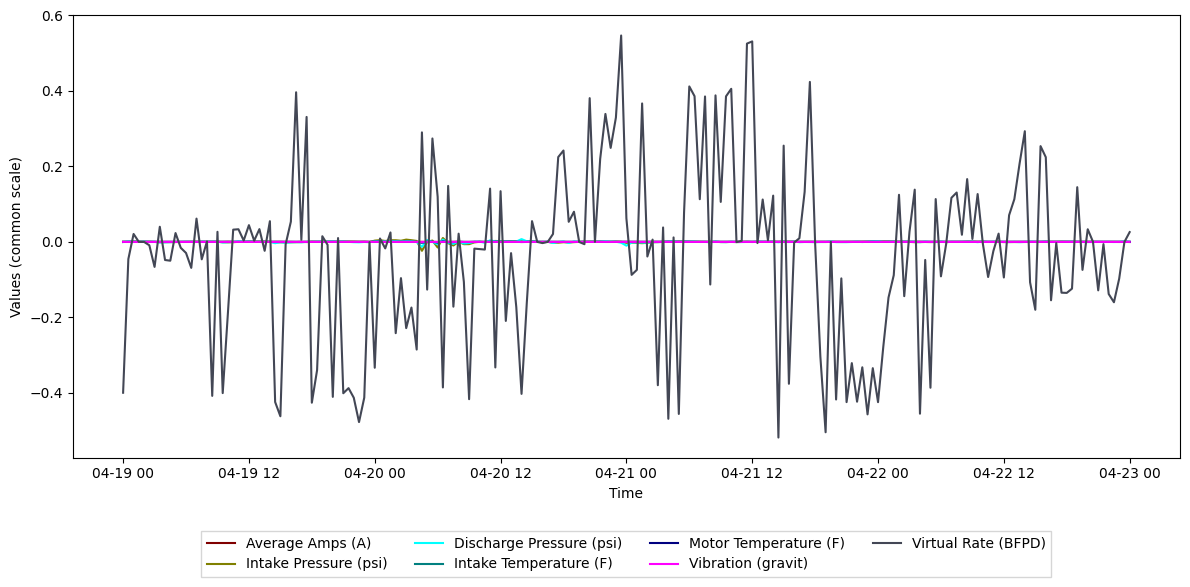

In [87]:
# Konversi kolom waktu
slopes_df["Window_Start_Time"] = pd.to_datetime(slopes_df["Window_Start_Time"])

# Buat rentang waktu ±2 hari
start_date = target_date - pd.Timedelta(days=2)
end_date = target_date + pd.Timedelta(days=2)

# Filter sesuai rentang
ready = slopes_df[(slopes_df["Window_Start_Time"] >= start_date) &
                  (slopes_df["Window_Start_Time"] <= end_date)]

# Cek apakah ada data
if ready.empty:
    print(f"Tidak ada data antara {start_date} dan {end_date}")
else:
    x = ready["Window_Start_Time"].to_numpy().ravel()

    # ======================
    # PLOTTING (1 sumbu Y)
    # ======================
    fig, ax = plt.subplots(figsize=(12, 6))

    p1, = ax.plot(x, ready["A"].to_numpy().ravel(), label="Average Amps (A)", color='#800000')
    p2, = ax.plot(x, ready["IP"].to_numpy().ravel(), label="Intake Pressure (psi)", color='#808000')
    p3, = ax.plot(x, ready["DP"].to_numpy().ravel(), label="Discharge Pressure (psi)", color='#00ffff')
    p4, = ax.plot(x, ready["IT"].to_numpy().ravel(), label="Intake Temperature (F)", color='#018080')
    p5, = ax.plot(x, ready["MT"].to_numpy().ravel(), label="Motor Temperature (F)", color='#000080')
    p6, = ax.plot(x, ready["V"].to_numpy().ravel(), label="Vibration (gravit)", color='#ff00ff')
    p7, = ax.plot(x, ready["R"].to_numpy().ravel(), label="Virtual Rate (BFPD)", color='#434755')

    ax.set_xlabel("Time")
    ax.set_ylabel("Values (common scale)")

    # Legend
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
              fancybox=False, shadow=False, ncol=4)

    plt.tight_layout()
    plt.show()

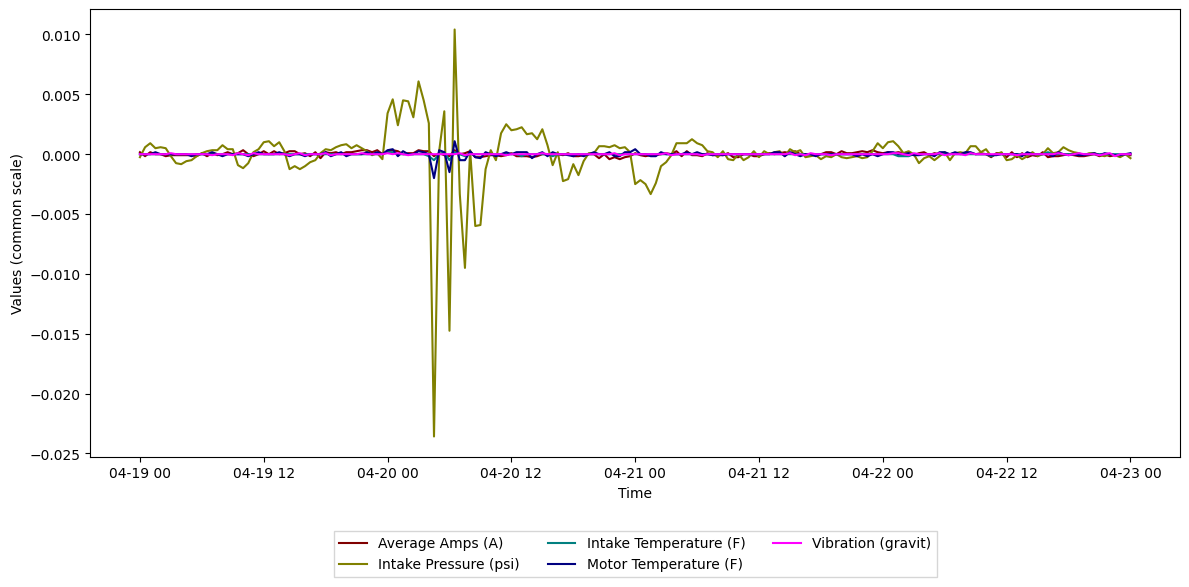

In [88]:
# Konversi kolom waktu
slopes_df["Window_Start_Time"] = pd.to_datetime(slopes_df["Window_Start_Time"])

# Buat rentang waktu ±2 hari
start_date = target_date - pd.Timedelta(days=2)
end_date = target_date + pd.Timedelta(days=2)

# Filter sesuai rentang
ready = slopes_df[(slopes_df["Window_Start_Time"] >= start_date) &
                  (slopes_df["Window_Start_Time"] <= end_date)]

# Cek apakah ada data
if ready.empty:
    print(f"Tidak ada data antara {start_date} dan {end_date}")
else:
    x = ready["Window_Start_Time"].to_numpy().ravel()

    # ======================
    # PLOTTING (1 sumbu Y, tanpa DP & R)
    # ======================
    fig, ax = plt.subplots(figsize=(12, 6))

    p1, = ax.plot(x, ready["A"].to_numpy().ravel(), label="Average Amps (A)", color='#800000')
    p2, = ax.plot(x, ready["IP"].to_numpy().ravel(), label="Intake Pressure (psi)", color='#808000')
    p3, = ax.plot(x, ready["IT"].to_numpy().ravel(), label="Intake Temperature (F)", color='#018080')
    p4, = ax.plot(x, ready["MT"].to_numpy().ravel(), label="Motor Temperature (F)", color='#000080')
    p5, = ax.plot(x, ready["V"].to_numpy().ravel(), label="Vibration (gravit)", color='#ff00ff')

    ax.set_xlabel("Time")
    ax.set_ylabel("Values (common scale)")

    # Legend
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
              fancybox=False, shadow=False, ncol=3)

    plt.tight_layout()
    plt.show()

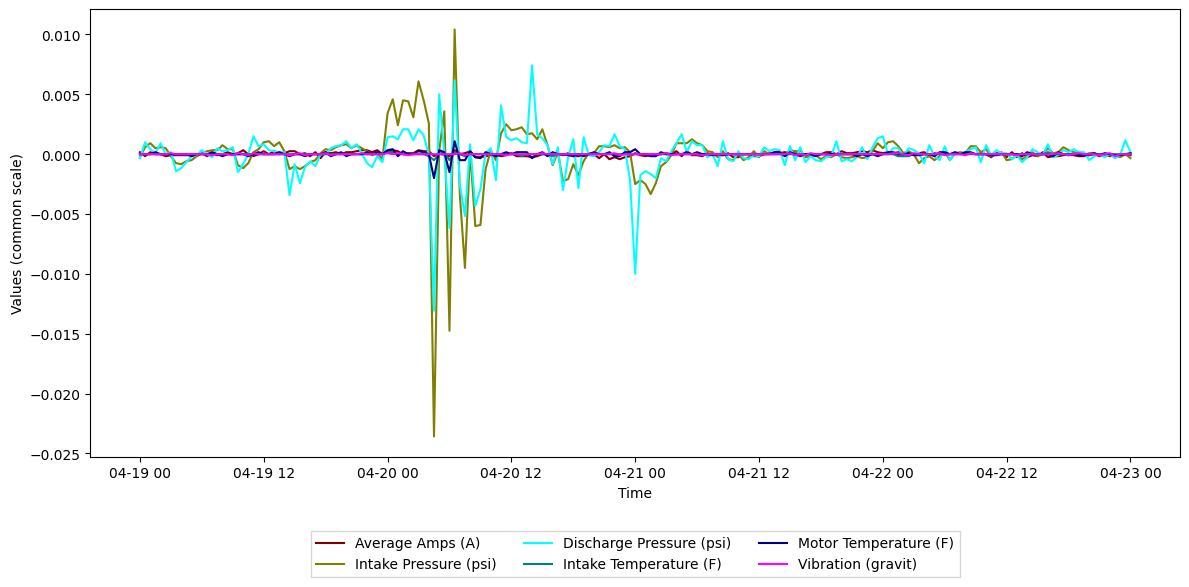

In [89]:
# Konversi kolom waktu
slopes_df["Window_Start_Time"] = pd.to_datetime(slopes_df["Window_Start_Time"])

# Buat rentang waktu ±2 hari
start_date = target_date - pd.Timedelta(days=2)
end_date = target_date + pd.Timedelta(days=2)

# Filter sesuai rentang
ready = slopes_df[(slopes_df["Window_Start_Time"] >= start_date) &
                  (slopes_df["Window_Start_Time"] <= end_date)]

# Cek apakah ada data
if ready.empty:
    print(f"Tidak ada data antara {start_date} dan {end_date}")
else:
    x = ready["Window_Start_Time"].to_numpy().ravel()

    # ======================
    # PLOTTING (1 sumbu Y, dengan DP tapi tanpa R)
    # ======================
    fig, ax = plt.subplots(figsize=(12, 6))

    p1, = ax.plot(x, ready["A"].to_numpy().ravel(), label="Average Amps (A)", color='#800000')
    p2, = ax.plot(x, ready["IP"].to_numpy().ravel(), label="Intake Pressure (psi)", color='#808000')
    p3, = ax.plot(x, ready["DP"].to_numpy().ravel(), label="Discharge Pressure (psi)", color='#00ffff')
    p4, = ax.plot(x, ready["IT"].to_numpy().ravel(), label="Intake Temperature (F)", color='#018080')
    p5, = ax.plot(x, ready["MT"].to_numpy().ravel(), label="Motor Temperature (F)", color='#000080')
    p6, = ax.plot(x, ready["V"].to_numpy().ravel(), label="Vibration (gravit)", color='#ff00ff')

    ax.set_xlabel("Time")
    ax.set_ylabel("Values (common scale)")

    # Legend
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
              fancybox=False, shadow=False, ncol=3)

    plt.tight_layout()
    plt.show()

# LEGEND LENGKAP

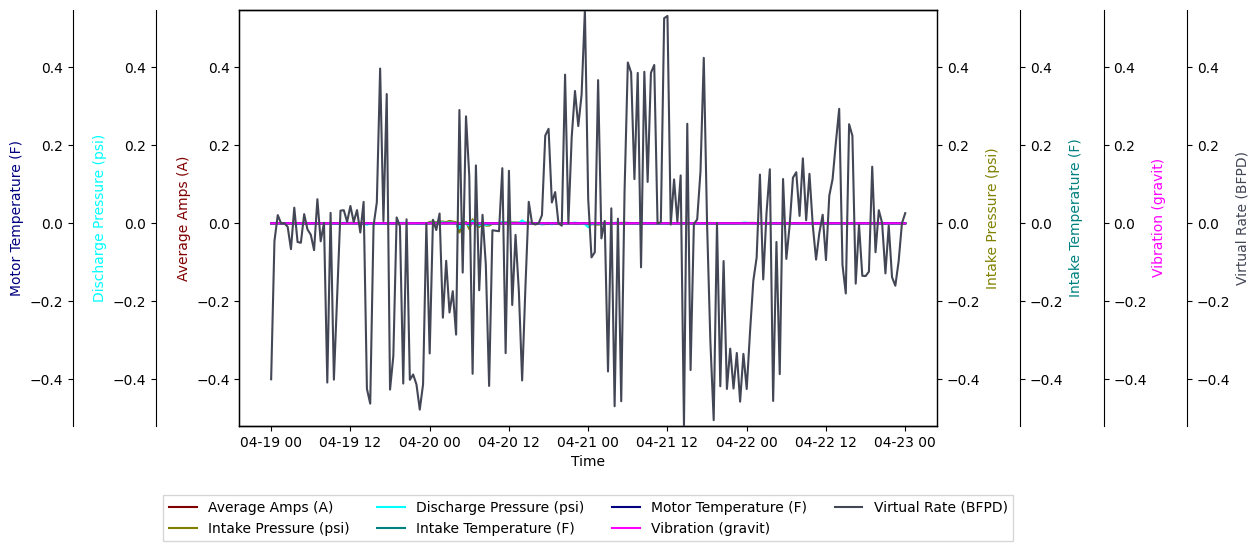

In [90]:
# Konversi kolom waktu
slopes_df["Window_Start_Time"] = pd.to_datetime(slopes_df["Window_Start_Time"])

# Buat rentang waktu ±2 hari
start_date = target_date - pd.Timedelta(days=2)
end_date = target_date + pd.Timedelta(days=2)

# Filter sesuai rentang
ready = slopes_df[(slopes_df["Window_Start_Time"] >= start_date) &
                  (slopes_df["Window_Start_Time"] <= end_date)]

# Cek apakah ada data
if ready.empty:
    print(f"Tidak ada data antara {start_date} dan {end_date}")
else:
    # pastikan jadi array 1D
    x = ready["Window_Start_Time"].to_numpy().ravel()

    # hitung global min/max semua kolom
    cols = ["A", "IP", "DP", "IT", "MT", "V", "R"]
    y_min = ready[cols].min().min()
    y_max = ready[cols].max().max()

    # ======================
    # PLOTTING
    # ======================
    fig = plt.figure(figsize=(12, 6))
    host = fig.add_subplot(111)

    par1 = host.twinx()
    par2 = host.twinx()
    par3 = host.twinx()
    par4 = host.twinx()
    par5 = host.twinx()
    par6 = host.twinx()

    host.set_xlabel("Time")
    host.set_ylabel("Average Amps (A)")
    par1.set_ylabel("Intake Pressure (psi)")
    par2.set_ylabel("Discharge Pressure (psi)")
    par3.set_ylabel("Intake Temperature (F)")
    par4.set_ylabel("Motor Temperature (F)")
    par5.set_ylabel("Vibration (gravit)")
    par6.set_ylabel("Virtual Rate (BFPD)")

    p1, = host.plot(x, ready["A"].to_numpy().ravel(), color='#800000', label="Average Amps (A)")
    p2, = par1.plot(x, ready["IP"].to_numpy().ravel(), color='#808000', label="Intake Pressure (psi)")
    p3, = par2.plot(x, ready["DP"].to_numpy().ravel(), color='#00ffff', label="Discharge Pressure (psi)")
    p4, = par3.plot(x, ready["IT"].to_numpy().ravel(), color='#018080', label="Intake Temperature (F)")
    p5, = par4.plot(x, ready["MT"].to_numpy().ravel(), color='#000080', label="Motor Temperature (F)")
    p6, = par5.plot(x, ready["V"].to_numpy().ravel(), color='#ff00ff', label="Vibration (gravit)")
    p7, = par6.plot(x, ready["R"].to_numpy().ravel(), color='#434755', label="Virtual Rate (BFPD)")

    # Shrink axis supaya muat legend
    box = host.get_position()
    host.set_position([box.x0, box.y0, box.width * 0.75, box.height * 0.9])

    # Legend
    lns = [p1, p2, p3, p4, p5, p6, p7]
    host.legend(handles=lns, loc='upper center', bbox_to_anchor=(0.5, -0.15),
                fancybox=False, shadow=False, ncol=4)

    # Spines & ticks
    par2.spines['left'].set_position(('outward', 60))
    par3.spines['right'].set_position(('outward', 60))
    par4.spines['left'].set_position(('outward', 120))
    par5.spines['right'].set_position(('outward', 120))
    par6.spines['right'].set_position(('outward', 180))

    par2.yaxis.set_ticks_position('left')
    par3.yaxis.set_ticks_position('right')
    par4.yaxis.set_ticks_position('left')
    par5.yaxis.set_ticks_position('right')
    par6.yaxis.set_ticks_position('right')

    par2.yaxis.set_label_position('left')
    par3.yaxis.set_label_position('right')
    par4.yaxis.set_label_position('left')
    par5.yaxis.set_label_position('right')
    par6.yaxis.set_label_position('right')

    # Warna label sesuai plot
    host.yaxis.label.set_color(p1.get_color())
    par1.yaxis.label.set_color(p2.get_color())
    par2.yaxis.label.set_color(p3.get_color())
    par3.yaxis.label.set_color(p4.get_color())
    par4.yaxis.label.set_color(p5.get_color())
    par5.yaxis.label.set_color(p6.get_color())
    par6.yaxis.label.set_color(p7.get_color())

    # ======================
    # Sama skala Y untuk semua axes
    # ======================
    for ax in [host, par1, par2, par3, par4, par5, par6]:
        ax.set_ylim(y_min, y_max)

    plt.show()

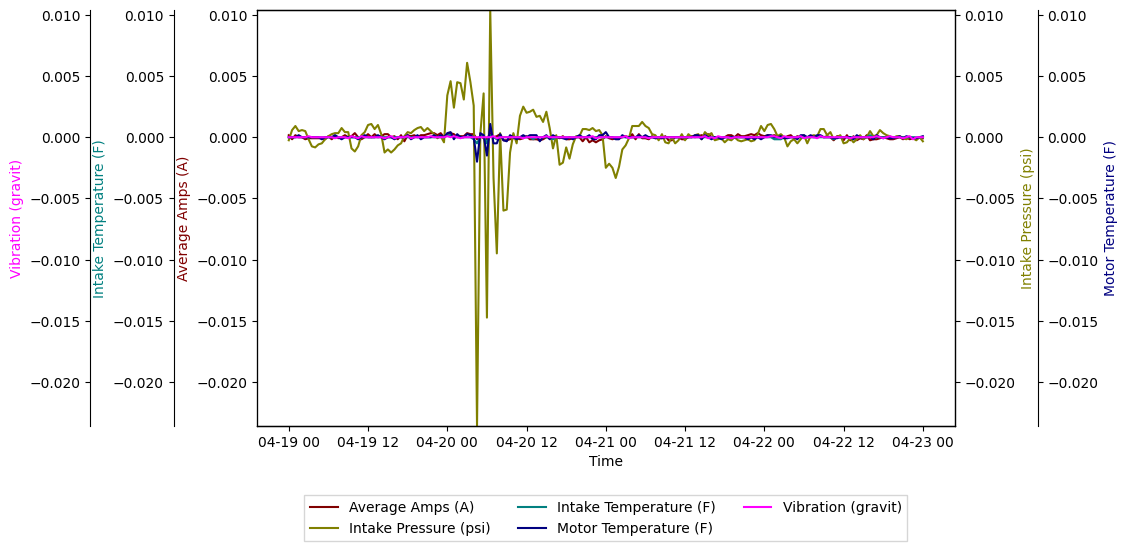

In [91]:
# Konversi kolom waktu
slopes_df["Window_Start_Time"] = pd.to_datetime(slopes_df["Window_Start_Time"])

# Buat rentang waktu ±2 hari
start_date = target_date - pd.Timedelta(days=2)
end_date = target_date + pd.Timedelta(days=2)

# Filter sesuai rentang
ready = slopes_df[(slopes_df["Window_Start_Time"] >= start_date) &
                  (slopes_df["Window_Start_Time"] <= end_date)]

# Cek apakah ada data
if ready.empty:
    print(f"Tidak ada data antara {start_date} dan {end_date}")
else:
    # pastikan jadi array 1D
    x = ready["Window_Start_Time"].to_numpy().ravel()

    # ======================
    # PLOTTING
    # ======================
    fig = plt.figure(figsize=(12, 6))
    host = fig.add_subplot(111)

    par1 = host.twinx()
    par2 = host.twinx()
    par3 = host.twinx()
    par4 = host.twinx()

    host.set_xlabel("Time")
    host.set_ylabel("Average Amps (A)")
    par1.set_ylabel("Intake Pressure (psi)")
    par2.set_ylabel("Intake Temperature (F)")
    par3.set_ylabel("Motor Temperature (F)")
    par4.set_ylabel("Vibration (gravit)")

    # Plot data
    p1, = host.plot(x, ready["A"].to_numpy().ravel(), color='#800000', label="Average Amps (A)")
    p2, = par1.plot(x, ready["IP"].to_numpy().ravel(), color='#808000', label="Intake Pressure (psi)")
    p3, = par2.plot(x, ready["IT"].to_numpy().ravel(), color='#018080', label="Intake Temperature (F)")
    p4, = par3.plot(x, ready["MT"].to_numpy().ravel(), color='#000080', label="Motor Temperature (F)")
    p5, = par4.plot(x, ready["V"].to_numpy().ravel(), color='#ff00ff', label="Vibration (gravit)")

    # Atur posisi axis tambahan
    par2.spines['left'].set_position(('outward', 60))
    par3.spines['right'].set_position(('outward', 60))
    par4.spines['left'].set_position(('outward', 120))

    par2.yaxis.set_ticks_position('left')
    par3.yaxis.set_ticks_position('right')
    par4.yaxis.set_ticks_position('left')

    par2.yaxis.set_label_position('left')
    par3.yaxis.set_label_position('right')
    par4.yaxis.set_label_position('left')

    # Samakan skala semua axis
    all_values = pd.concat([
        ready["A"], ready["IP"], ready["IT"], ready["MT"], ready["V"]
    ], axis=0).to_numpy().ravel()

    ymin, ymax = all_values.min(), all_values.max()
    for ax in [host, par1, par2, par3, par4]:
        ax.set_ylim(ymin, ymax)

    # Shrink axis supaya muat legend
    box = host.get_position()
    host.set_position([box.x0, box.y0, box.width * 0.75, box.height * 0.9])

    # Legend
    lns = [p1, p2, p3, p4, p5]
    host.legend(handles=lns, loc='upper center', bbox_to_anchor=(0.5, -0.15),
                fancybox=False, shadow=False, ncol=3)

    # Warna label sesuai plot
    host.yaxis.label.set_color(p1.get_color())
    par1.yaxis.label.set_color(p2.get_color())
    par2.yaxis.label.set_color(p3.get_color())
    par3.yaxis.label.set_color(p4.get_color())
    par4.yaxis.label.set_color(p5.get_color())

    plt.show()